In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
plt.figure(figsize = (10,6))
sns.set(style = "whitegrid")

<Figure size 1000x600 with 0 Axes>

In [4]:
df = pd.read_csv("demand_forecasting.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df.dtypes


Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object

feature engineering on dates

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [33]:
df["Discounted_Price"] = df["Price"] * (1 - df["Discount"] / 100)
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Sell Through Rate,Discounted_Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,0.523077,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,1.000000,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,0.461538,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,0.323741,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,0.427632,54.410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,0.270386,28.310
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,0.839416,40.774
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,0.223350,16.029
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,0.464000,151.720


In [8]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,0,32.23,Winter,0,64,2024,1,30,Tuesday,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,0,40.73,Winter,0,137,2024,1,30,Tuesday,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,0,19.41,Winter,0,68,2024,1,30,Tuesday,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,0,143.71,Winter,0,84,2024,1,30,Tuesday,0.464000


In [9]:
df["Sell Through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

Calculating Demand by Categories

In [10]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(by = "sum", ascending = False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


Calculating Demand by 'region' and 'seasonality'

In [11]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

Calculating Demand by Promotion

In [12]:
df.groupby("Promotion")["Demand"].mean()

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

Monthly demand by Category

In [13]:
pd.pivot_table(df, values = "Demand", index = "Month", columns = "Category", aggfunc = "mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


Creating a Distribution Visualization

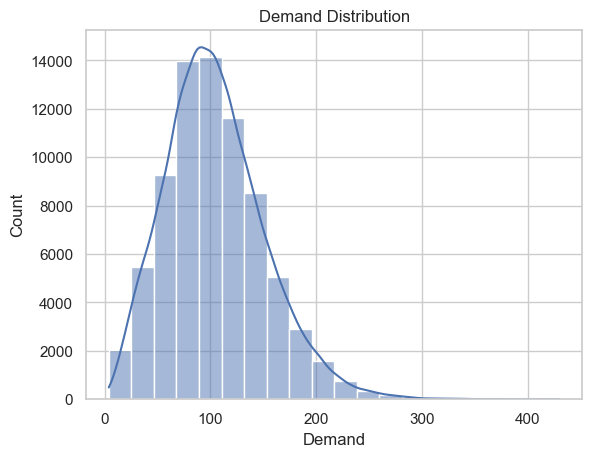

In [14]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Demand Distribution")
plt.show()

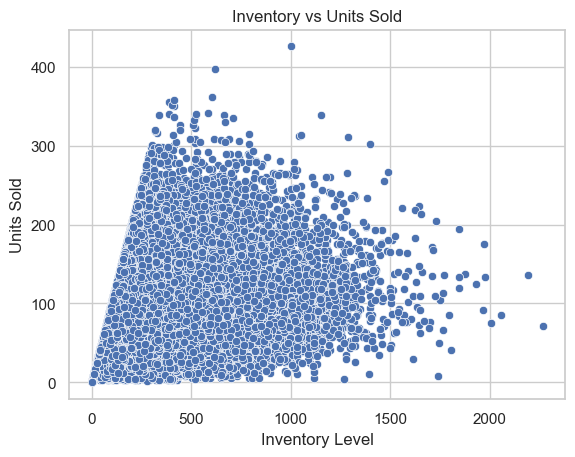

In [15]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory vs Units Sold")
plt.show()

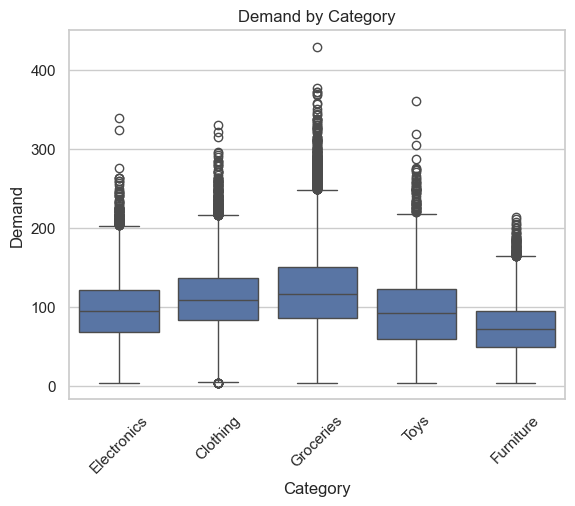

In [16]:
sns.boxplot(data = df, x = "Category", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Category")
plt.show()

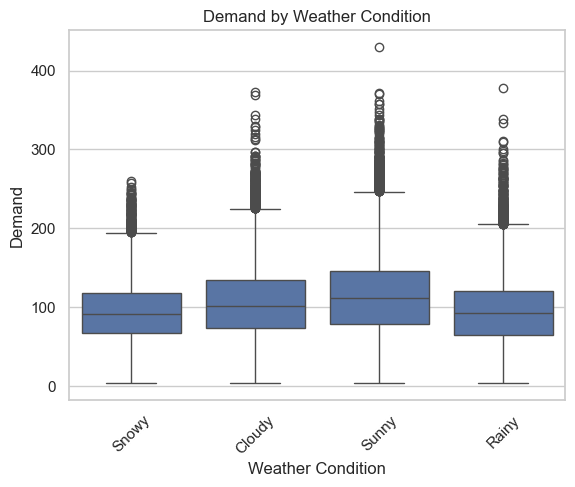

In [17]:
sns.boxplot(data = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Weather Condition")
plt.show()

In [19]:
monthly_demand = df.groupby("Month")["Demand"].mean()

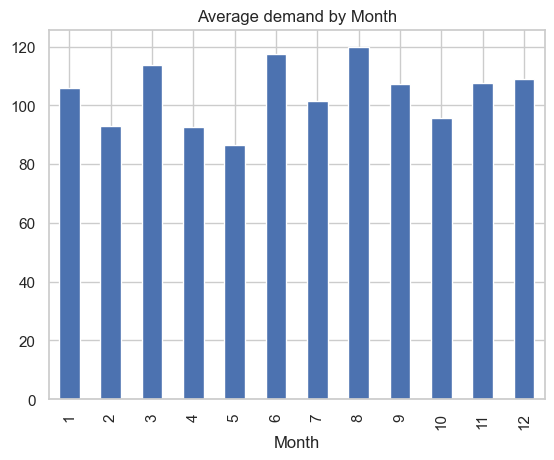

In [20]:
monthly_demand.plot(kind = "bar")
plt.title("Average demand by Month")
plt.show()

In [26]:
daily_demand = df.groupby("Date")["Demand"].sum()
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

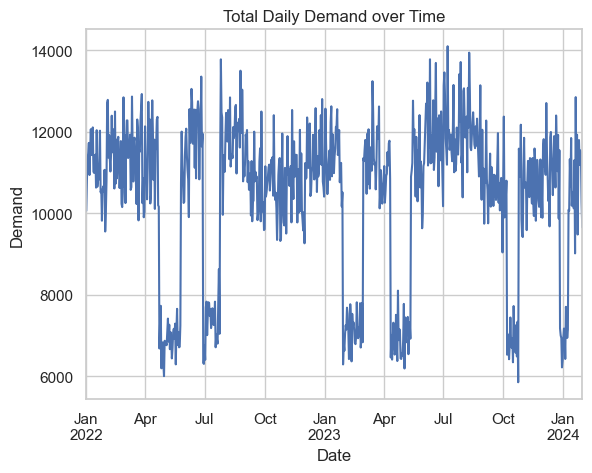

In [27]:
daily_demand.plot()
plt.title("Total Daily Demand over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

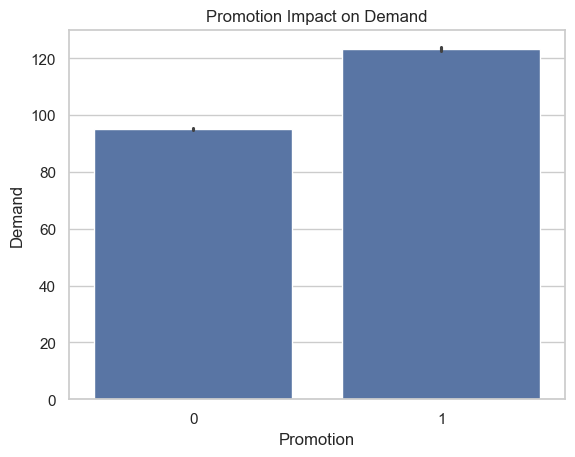

In [28]:
sns.barplot(data = df, x = "Promotion", y = "Demand")
plt.title("Promotion Impact on Demand")
plt.show()

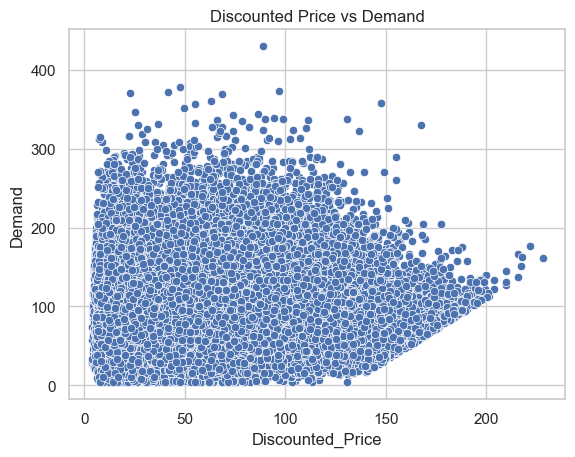

In [34]:
sns.scatterplot(data = df, x = "Discounted_Price", y = "Demand")
plt.title("Discounted Price vs Demand")
plt.show()

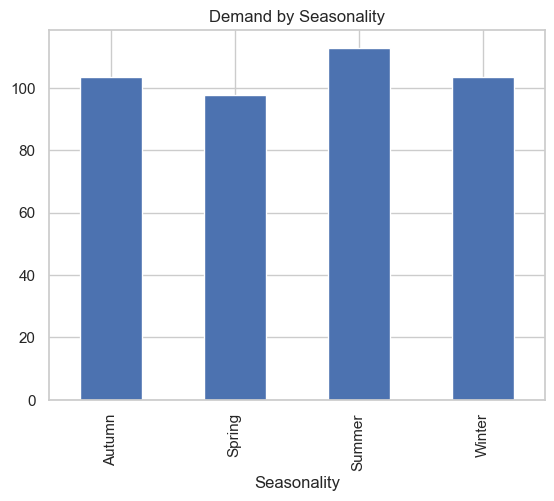

In [35]:
df.groupby("Seasonality")["Demand"].mean().plot(kind = "bar", title = "Demand by Seasonality")
plt.show()

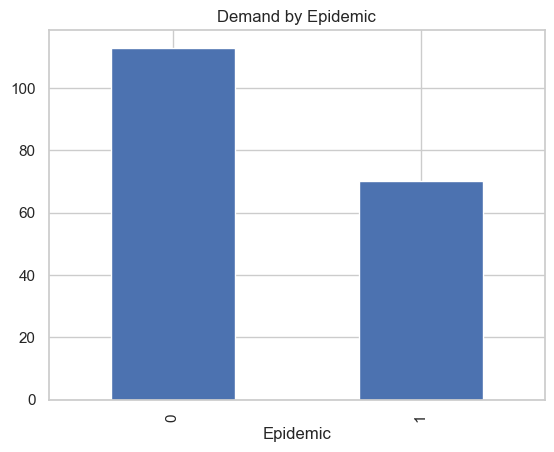

In [36]:
df.groupby("Epidemic")["Demand"].mean().plot(kind = "bar", title = "Demand by Epidemic")
plt.show()